<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print(f"Acurácia no treino: {acc_train:.2f}")
print(f"Acurácia no teste: {acc_test:.2f}")

Acurácia no treino: 1.00
Acurácia no teste: 0.93


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

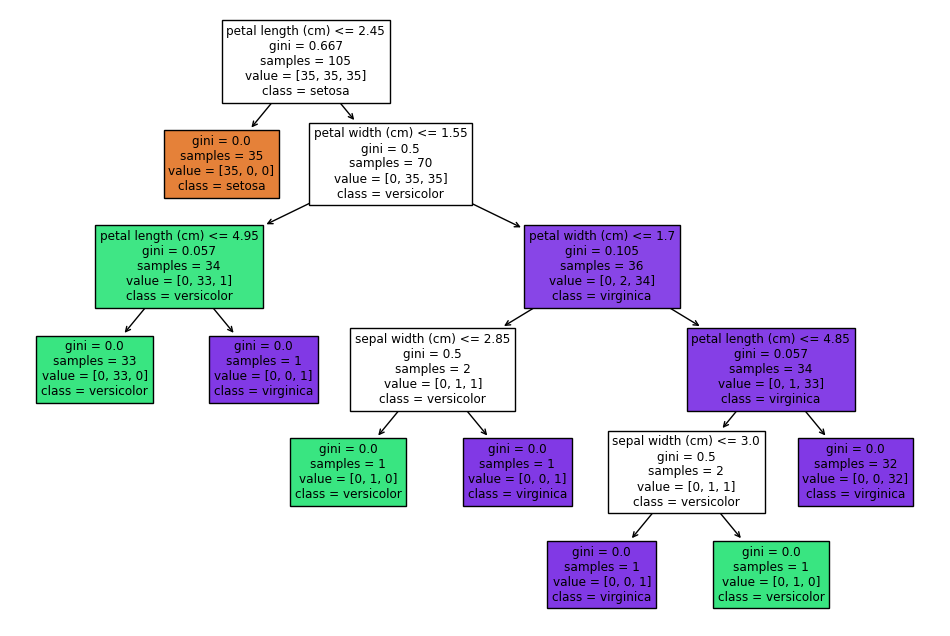

In [8]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names.tolist(),
    filled=True
)
plt.show()

1. Qual atributo aparece na raiz? 
R: O atributo raiz é o comprimento da pétala em cm.

In [ ]:
# 2. Qual é a profundidade da árvore?
print("A profundidade da arvore é: ", model.get_depth())

A profundidade da arvore é:  5


# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [14]:
import pandas as pd

depths = list(range(1, 10)) + [None]

resultados = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    # Previsões
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Métricas
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)
    depth_real = model.get_depth()
    n_leaves = model.get_n_leaves()

    resultados.append({
        "max_depth": d,
        "acc_treino": acc_train,
        "acc_teste": acc_test,
        "profundidade": depth_real,
        "n_folhas": n_leaves
    })

df = pd.DataFrame(resultados)
print(df.to_string (index=False))

 max_depth  acc_treino  acc_teste  profundidade  n_folhas
       1.0    0.666667   0.666667             1         2
       2.0    0.971429   0.888889             2         3
       3.0    0.980952   0.977778             3         5
       4.0    0.990476   0.888889             4         7
       5.0    1.000000   0.933333             5         8
       6.0    1.000000   0.933333             5         8
       7.0    1.000000   0.933333             5         8
       8.0    1.000000   0.933333             5         8
       9.0    1.000000   0.933333             5         8
       NaN    1.000000   0.933333             5         8


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

Resposta: Quandoo temos overfitting, o modelo começa a se ajustar demais aos dados de treino. Com isso, com max_depth = 4, temos a acurácia de treino (0.990476) > acurácia de teste (0.888889). Quando definimos max_depth = none, a árvore cresce sem limite até que não seja mais possível fazer divisões ou cada folha fique "pura". Dessa forma, o modelo aprende até o ruído, se ajustando perfeitamente aos dados do treino, por isso a acurácia de treino é 100%.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [16]:
criterios = ["gini", "entropy"]
resultados = []

for c in criterios:
    model = DecisionTreeClassifier(criterion=c, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    resultados.append({
        "criterion": c,
        "acc_treino": accuracy_score(y_train, y_train_pred),
        "acc_teste": accuracy_score(y_test, y_test_pred),
        "profundidade": model.get_depth(),
        "n_folhas": model.get_n_leaves()
    })

df = pd.DataFrame(resultados)
print(df.to_string (index=False))

criterion  acc_treino  acc_teste  profundidade  n_folhas
     gini         1.0   0.933333             5         8
  entropy         1.0   0.888889             6         8


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**: